# Trabajo Práctico: Análisis de Opiniones de Usuarios en Yelp con NLP

## Descripción General

Yelp es una plataforma ampliamente utilizada para reseñar negocios locales. En este trabajo práctico, vas a analizar un conjunto de datos que contiene reseñas de usuarios con el objetivo de extraer información relevante que pueda aportar valor a la unidad de negocio.

El equipo de Diseño de Producto de Yelp ha puesto a disposición del área de Data Science un conjunto de reseñas recopiladas durante varios meses. Tu desafío será analizar estas opiniones para descubrir insights significativos que puedan mejorar la toma de decisiones estratégicas.

## Objetivo

Aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) para generar un análisis profundo de las reviews, con el fin de:

- Comprender mejor la experiencia de los usuarios.
- Identificar oportunidades de mejora para los negocios.
- Aportar valor a la toma de decisiones del equipo de producto.

## Consignas Obligatorias

Tu análisis debe incluir, como mínimo, los siguientes elementos:

- Extracción de palabras clave y tópicos por negocio (`business_id`).
- Análisis de sentimiento para cada review.
- Extracción de entidades nombradas (NER) por review.
- Identificación del negocio con mayor cantidad de comentarios positivos.
- Identificación del negocio con mayor cantidad de comentarios negativos.

## Análisis Opcionales (Sugeridos)

Puedes enriquecer tu análisis explorando, por ejemplo:

- Relación entre tópicos y sentimientos.
- Asociación de keywords con emociones.
- Evolución del sentimiento a lo largo del tiempo.
- Cualquier otro hallazgo relevante que descubras durante el análisis.

Nota: No hay límites en la profundidad de tu exploración. El objetivo es generar valor para el negocio.

## Datos

**Archivo principal:** `yelp_reviews.csv`

Recomendaciones:

- Familiarizarte con las columnas disponibles.
- Investigar si Yelp ofrece repositorios públicos adicionales (descargables o vía API) con más features o datos actualizados (exploratorio, no obligatorio).

## Entrega del Notebook

- Formato: Jupyter Notebook (.ipynb)
- Fecha de entrega: A definir junto al docente.

## Presentación de Resultados

**Contexto:** Vas a presentar tus hallazgos al equipo de Data Science y a los líderes del área de Diseño de Producto.

**Formato:** Presentación en diapositivas (NO es una presentación del notebook).

La presentación debe incluir:

- Resultados e insights clave obtenidos.
- Herramientas y técnicas utilizadas.
- Recomendaciones y decisiones de negocio basadas en el análisis.
- Conclusiones principales.

## Librerias

In [14]:
!pip install keybert
!pip install bertopic
!python -m spacy download en_core_web_trf
!pip install spacy-curated-transformers
!pip install -U spacy spacy-curated-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [1]:
from functools import partial
import ast

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
import pandas as pd
import numpy as np

In [12]:
from matplotlib import pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [16]:
import spacy
from textblob import TextBlob
from bertopic import BERTopic
from keybert import KeyBERT
import re

In [17]:
nlp = spacy.load("en_core_web_trf")

Funciones y clases

In [ ]:
class ExtractDatePart(BaseEstimator, TransformerMixin):
  def __init__(self, column_date_name: str, extract_year: bool = False, extract_month: bool = False, extract_day: bool = False, extract_week: bool = False):
    self.column_date_name = column_date_name
    self.extract_year = extract_year
    self.extract_month = extract_month
    self.extract_day = extract_day
    self.extract_week = extract_week

  def fit(self, X: pd.Series | pd.DataFrame = None, y=None):
    if isinstance(X, pd.DataFrame):
      self.features_names_in_ = X.columns
    elif isinstance(X, pd.Series):
      self.features_names_in_ = X.name

    return self

  def transform(self, X, y=None):
    self.date_columns_transformed_ = pd.DataFrame()

    if self.extract_year == True:
      self.year_ = X[self.column_date_name].dt.year
      self.date_columns_transformed_[self.column_date_name + '_year'] = self.year_
    if self.extract_month == True:
      self.month_ = X[self.column_date_name].dt.month
      self.date_columns_transformed_[self.column_date_name + '_month'] = self.month_
    if self.extract_day:
      self.day_ = X[self.column_date_name].dt.day
      self.date_columns_transformed_[self.column_date_name + '_day'] = self.day_
    if self.extract_week == True:
      self.week_ = X[self.column_date_name].dt.isocalendar()['week']
      self.date_columns_transformed_[self.column_date_name + '_week'] = self.week_

    return self.date_columns_transformed_


In [ ]:
def clean_text(text: str = None, s_characters_pattern: str = None, e_spaces: bool = False) -> str:
    '''
    This function receive text of dataframe into 'text' arg, patterns string of special characters to remove and declaration to remove spaces.
    Finally this function return the text preprocessed.

    args:
    text (string): Text from columns of dataframe.
    s_characters_pattern (string): String with special characters to remove.
    e_spaces (bool): Boolean value for delete or not delete spaces from string.

    returns:
    text (string): Preprocessed text from dataframe.
    '''
    if s_characters_pattern is not None:
        text = re.sub(s_characters_pattern, "", text)
    if e_spaces:
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
    return text

    return text

In [ ]:
def clean_normalize_text(doc: str = None, tokenizer=True, c_stop_w=False, c_punct=False, lemmatizer=False, lower=True):
    doc_clean_normalize = []
    if tokenizer and doc:
        for token in nlp(doc):
            # Primero tomamos el texto normal
            token_clean_norm = token.text

            # Saltar stopwords
            if c_stop_w and token.is_stop:
                continue

            # Saltar signos de puntuación
            if c_punct and token.is_punct:
                continue

            # Aplicar lematización si se solicita
            if lemmatizer:
                token_clean_norm = token.lemma_

            # Aplicar minúsculas si se solicita
            if lower:
                token_clean_norm = token_clean_norm.lower()

            doc_clean_normalize.append(token_clean_norm)

    return ' '.join(doc_clean_normalize)

In [ ]:
def get_noun_chunks(text: str, spacy_model=None):
    '''
    args:
    text (str): texto a extraer fraces nominales.
    spacy_model (str): Modelo de spacy a utilizar.

    returns:
    result (list): Lista de frases nomiales extraidas del texto.
    '''
    # instancio el texto utilizando la función previamente creada y el modelo especifico de SpaCy recibido como parametro
    doc = spacy_model(text)
    # Se obtienen las oraciones nominales en formato texto y se almacenan dentro de una lista
    result = [nc.text for nc in doc.noun_chunks]
    return result

In [ ]:
def get_entities(text:str):

  doc = nlp(text)
  ents = []

  if doc.ents:
    for ent in doc.ents:
      ents.append(ent.text)
      #ents.append(ent.label_)

  return ents

In [ ]:
def get_sentiment(text):
  sent = TextBlob(text).sentiment.polarity

  if sent > 0.1:
    return "POS"

  if sent >= -0.1 and sent <= 0.1:
    return "NEU"

  if sent < -0.1:
    return "NEG"

## Carga de datos

In [ ]:
id = '1KDZKP6sudF-Ft0adHsZuu7AjqeqQa4BR'
url = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(url)

In [ ]:
df = df.sample(random_state=42, frac=0.15)

In [ ]:
df.sample(3)

In [ ]:
df_limpio = df.copy()

## 0. EDA y pre-procesamiento

Columnas disponibles.


In [ ]:
df.sample(3)

In [ ]:
df.info()

- review_id: Identificador único de la reseña (cadena de 22 caracteres).
- user_id: Identificador del usuario que escribió la reseña (cadena de 22 caracteres).
- business_id: Identificador del negocio reseñado (cadena de 22 caracteres).
- stars: Calificación otorgada en estrellas (entero).
- date: Fecha de la reseña en formato YYYY-MM-DD.
- useful: Número de votos que consideran la reseña útil (entero).
- funny: Número de votos que consideran la reseña graciosa (entero).
- cool: Número de votos que consideran la reseña “cool” (entero).

Codificando ID's

In [ ]:
df_limpio['user_id'] = pd.factorize(df['user_id'])[0]

In [ ]:
df_limpio['review_id'] = pd.factorize(df['review_id'])[0]

In [ ]:
df_limpio['business_id'] = pd.factorize(df['business_id'])[0]

Columnas de fechas

In [ ]:
df_limpio['date'] = pd.to_datetime(df['date'], errors='coerce', yearfirst=True)

In [ ]:
extract_date = ExtractDatePart(column_date_name='date', extract_year=True, extract_month=True, extract_day=True)

In [ ]:
extract_date.fit(X = df_limpio)
year_month_day = extract_date.transform(X=df_limpio)

In [ ]:
df_limpio[['year', 'month', 'day']] = year_month_day

In [ ]:
df_limpio.drop(columns='date', inplace=True)

Repositorios públicos adicionales (descargables o vía API) con más features o datos actualizados (exploratorio, no obligatorio).

In [ ]:
# https://business.yelp.com/data/resources/open-dataset/

## 1. Limpieza y normalización

- 1.1. Limpieza previa del texto
    - Expresiones regulares para eliminación de caracteres especiales
    - Eliminación de espacios extra
    - Manejo de caracteres Unicode (acentos, tildes, etc.)

- 1.2. Normalización del texto con librerias como Spacy
    - Tokenización
    - Lematización
    - Eliminación de stop words
    - Eliminación de puntuaciones
    - Conversión a minúsculas
    - Expresiones regulares para filtrar contenido de interés
    - Traducción de texto

Limpieza

In [ ]:
clean_text_del_spaces = partial(clean_text, e_spaces=True)

In [ ]:
df_limpio['text'] = df_limpio['text'].apply(clean_text_del_spaces)

Normalización

In [ ]:
normalize_base_partial_function = partial(clean_normalize_text, tokenizer=True, c_stop_w=False, c_punct=True, lemmatizer=True, lower=False)

In [ ]:
df_limpio['text'] = df_limpio['text'].apply(normalize_base_partial_function)

## 2. Extracción de Información

- 2.1. Named Entity Recognition (NER)
    - Extracción de entidades
    - Frecuencia de entidades en los textos
    - Renderización y visualización de entidades

- 2.2. Análisis Léxico y Sintáctico
    - Part of Speech (POS tagging)
    - Noun chunks (grupos nominales)
    - Sentencier (detección de límites de oraciones)

- 2.3. Extracción de Keywords y Tópicos
    - Extracción de palabras clave
    - Identificación de tópicos clave

- 2.4. Análisis de Sentimiento
    - Subjetividad y polaridad (TextBlob, VADER, etc.)
    - Frecuencia de sentimientos (positivo, negativo, neutral)
    - Análisis de categorías gramaticales (sustantivos, adjetivos clasificados por sentimiento)

### Extracción de noun chunks

In [ ]:
nun_chunks_function = partial(get_noun_chunks, spacy_model=nlp)

In [ ]:
df_limpio['text_noun_chounks'] = df_limpio['text'].apply(nun_chunks_function)

In [ ]:
df_limpio.to_csv('./df_limpio_noun_c.csv')

### Extracción de palabras clave y tópicos por negocio (business_id).




#### Topicos clave

In [ ]:
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(df_limpio["text"].values)

In [ ]:
df_limpio["text_topic_id"] = topics

In [ ]:
df_limpio.to_csv('./df_limpio_topics.csv')

#### Palabras claves

In [ ]:
kw_model = KeyBERT()
text_keywords_partial_function = partial(kw_model.extract_keywords,top_n=3, keyphrase_ngram_range=(1,1))

In [ ]:
df_limpio["text_keywords"] = df_limpio['text'].apply(lambda x: [kw for kw, _ in text_keywords_partial_function(x)])

In [ ]:
df_limpio.to_csv('./df_limpio_keywords.csv')

### Extracción de sentimiento para cada review.




In [ ]:
df_limpio['text_sentiment'] = df_limpio['text'].apply(get_sentiment)

In [ ]:
df_limpio.to_csv('./df_limpio_sentiment.csv')

### Extracción de entidades nombradas (NER) por review.

In [ ]:
df_limpio['text_ner'] = df_limpio['text'].apply(get_entities)

In [ ]:
df_limpio.to_csv('./df_limpio_ner.csv')

## 3. Analisis de información

1. Nube de palabras
2. Graficos de frecuencia

In [4]:
# lectura del dataset con info extraida
id = '1nq5YqiU0qQu1SwJa35lVB9BnY03rA59l'
url = f'https://drive.google.com/uc?id={id}'
df_limpio = pd.read_csv(url)

In [5]:
df_limpio.sample(6)

,Unnamed: 0.1,Unnamed: 0,user_id,review_id,text,votes.cool,business_id,votes.funny,stars,type,votes.useful,year,month,day,text_noun_chounks,text_topic_id,text_sentiment,text_ner,text_keywords
577,577,91,545,577,never go to Rossi Tailoring and Dry Cleaners 3...,0,320,0,1,review,0,2013,1,21,"['Rossi Tailoring', 'Dry Cleaners', '393 Vanad...",0,NEU,"['Rossi Tailoring and Dry Cleaners', 'Pittsbur...","['cleaners', 'shirt', 'pa']"
496,496,17219,470,496,probably one of the good affordable ethnic pla...,1,194,0,4,review,1,2012,11,10,"['the good affordable ethnic place', 'uptown',...",0,POS,"['one', 'uptown', 'Basil']","['uptown', 'basil', 'crunch']"
268,268,15610,257,268,I do give this 4 star but I be update my revie...,0,195,0,3,review,0,2015,9,27,"['I', 'this', '4 star', 'my review', 'a recent...",0,NEU,"['4', 'Sunday', 'cheddar bay', 'September 2015...","['dining', 'bartender', 'shrimp']"
234,234,10249,227,234,I can not say enough about Merante 's and Mari...,0,173,0,5,review,1,2014,5,5,"['I', 'Merante', 'Maria', 'the back', 'the sho...",0,POS,"['Merante', 'Maria', 'Maria', '6', '8 10', 'th...","['meal', 'dinner', 'lunch']"
320,320,25100,306,320,what a fun place to get idea for your house th...,0,26,0,4,review,0,2013,9,1,"['what a fun place', 'idea', 'your house', 'th...",0,NEU,"['over 100', 'a few hour']","['furniture', 'booth', 'house']"
182,182,12978,178,182,I love this place for its salad this be the fi...,0,31,0,4,review,0,2009,9,22,"['I', 'this place', 'its salad', 'this', 'the ...",0,POS,"['first', 'the Pittsburgh Salad']","['salad', 'soup', 'onion']"


In [10]:
df_limpio.shape

(614, 19)

### Identificación del negocio con mayor cantidad de comentarios positivos.



In [28]:
mask_pos_sentiment = df_limpio['text_sentiment'] == 'POS'
df_pos_sentiment_by_business = df_limpio[mask_pos_sentiment].groupby(by=['business_id'], as_index=False)['text_sentiment'].count().sort_values(by='text_sentiment', ascending=False)
df_pos_sentiment_by_business[:5].reset_index(drop=True)

,business_id,text_sentiment
0,14,18
1,36,8
2,18,7
3,66,7
4,52,6


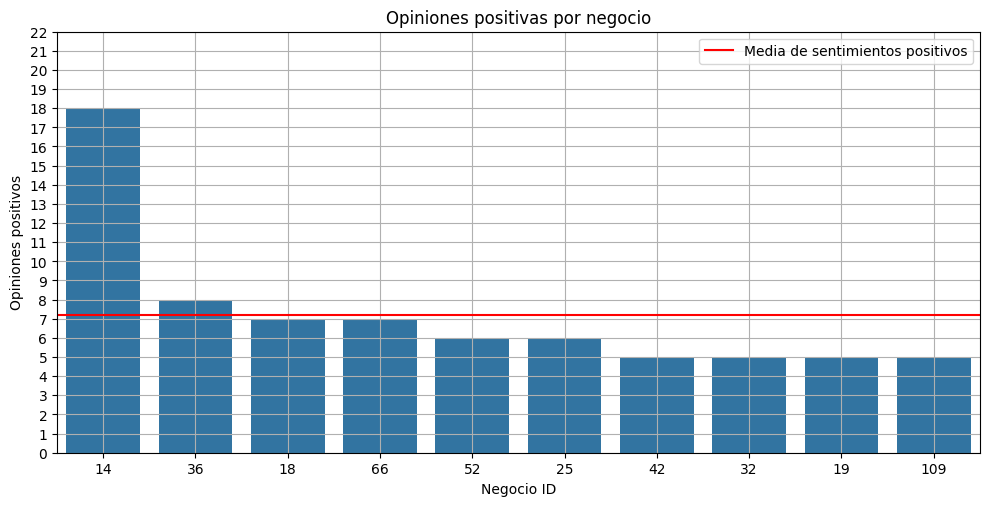

In [12]:
fig = plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_pos_sentiment_by_business[:10].reset_index(), x='business_id', y='text_sentiment', order=df_pos_sentiment_by_business[:10]['business_id'])
plt.yticks(np.arange(0, max(df_pos_sentiment_by_business[:10]['text_sentiment']+5), 1))
plt.axhline(y=np.mean(df_pos_sentiment_by_business[:10]['text_sentiment']), color='r', label='Media de sentimientos positivos')
plt.grid()
plt.tight_layout()
plt.title('Opiniones positivas por negocio')
plt.xlabel('Negocio ID')
plt.ylabel('Opiniones positivos')
plt.legend()
plt.show()

El negocio con mayor cantidad de comentarios positivos es el negocio con el id 14.

Top 3 negocios con comentarios positivos:
- bussines id 14: 18 comentarios positivos.
- bussines id 36: 8 comentarios positivos.
- bussines id 18: 7 comentarios positivos.

#### Noun chunks para bussines con mas opiniones positivas

In [18]:
df_limpio_most_positives_mask = df_limpio['business_id'] == 14 | 36 | 18
df_limpio_most_positives = df_limpio[df_limpio_most_positives_mask]['text_noun_chounks']

In [19]:
word_cloud = WordCloud(collocations = False, # combinación de palabras encontradas juntas
                       background_color = 'white',
                       width = 800, height = 800,
                       stopwords = nlp.Defaults.stop_words,
                       ).generate(str(df_limpio_most_positives.values))

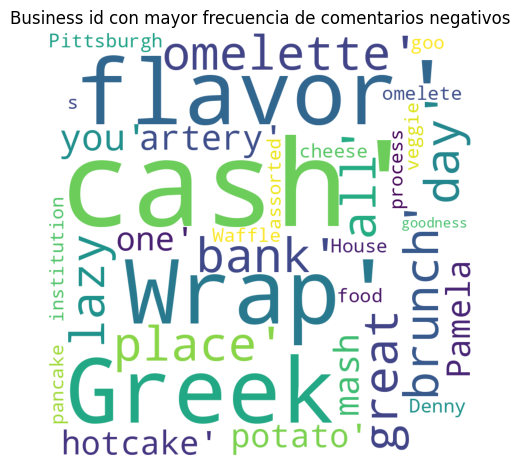

In [21]:
plt.figure(figsize=(10, 5))
plt.imshow(word_cloud)
plt.title('Business id con mayor frecuencia de comentarios negativos')
plt.tight_layout()
plt.axis('off')
plt.show()

Los usuarios parecen valorar cosas como el sabor, platos griegos, las tortas, el lugar, los ommetletes, el buen precio, comida vegana, la opcion de comida a media mańana, el proceso con el que se gestiona el servicio, y la amavilidad de los empleados.

Seria interesante enfocarse en sostener y mejorar estos puntos en los diferentes negocios de comida.

### Identificación del negocio con mayor cantidad de comentarios negativos.



In [27]:
mask_neg_sentiment = df_limpio['text_sentiment'] == 'NEG'
df_neg_sentiment_by_business = df_limpio[mask_neg_sentiment].groupby(by='business_id', as_index=False)['text_sentiment'].count().sort_values(by='text_sentiment', ascending=False)
df_neg_sentiment_by_business[:5]

,business_id,text_sentiment
23,192,2
0,0,1
2,7,1
1,3,1
3,14,1


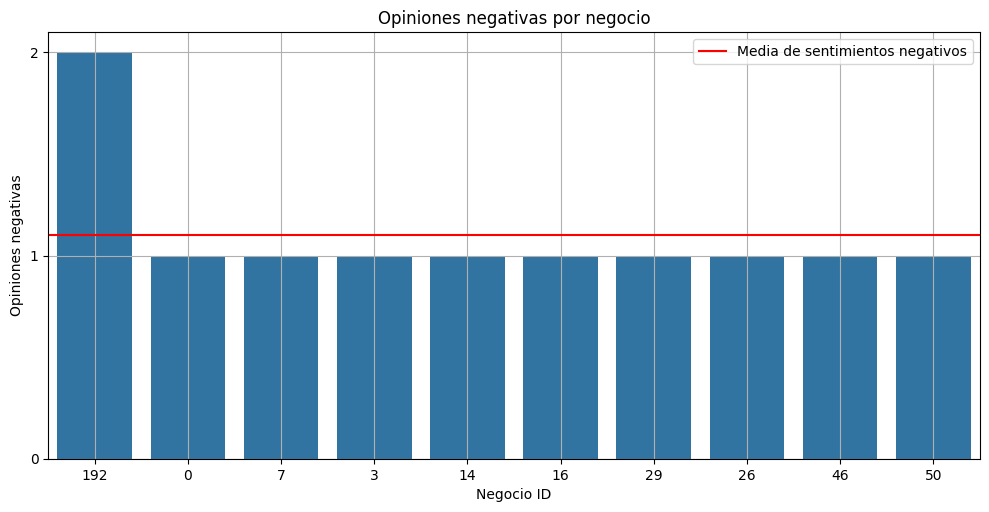

In [14]:
fig = plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_neg_sentiment_by_business[:10].reset_index(), x='business_id', y='text_sentiment', order=df_neg_sentiment_by_business[:10]['business_id'])
plt.yticks(np.arange(0, max(df_neg_sentiment_by_business[:10]['text_sentiment']+1), 1))
plt.axhline(y=np.mean(df_neg_sentiment_by_business[:10]['text_sentiment']), color='r', label='Media de sentimientos negativos')
plt.grid()
plt.tight_layout()
plt.title('Opiniones negativas por negocio')
plt.xlabel('Negocio ID')
plt.ylabel('Opiniones negativas')
plt.legend()
plt.show()

El negocio con mayor cantidad de comentarios negativos es el negocio con el id 192.

Top 3 negocios con comentarios positivos:
- bussines id 192: 2 comentarios positivos.
- bussines id 0: 1 comentarios positivos.
- bussines id 7: 1 comentarios positivos.

#### Noun chunks para bussines con mas opiniones negativas

In [29]:
df_limpio_most_negatives = df_limpio[mask_neg_sentiment]['text_noun_chounks']

In [40]:
customized_stop_wrods = nlp.Defaults.stop_words.union({"she'", "you'", "they", "they'","it'", "I'", "that'"})

In [41]:
word_cloud = WordCloud(collocations = False, # combinación de palabras encontradas juntas
                       background_color = 'white',
                       width = 800, height = 800,
                       stopwords = customized_stop_wrods,
                       ).generate(str(df_limpio_most_negatives.values))

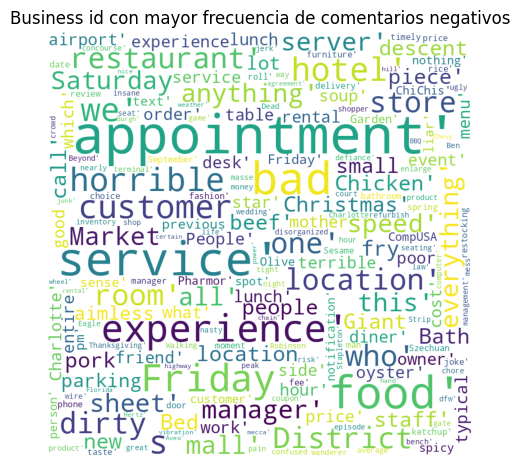

In [42]:
plt.figure(figsize=(10, 5))
plt.imshow(word_cloud)
plt.title('Business id con mayor frecuencia de comentarios negativos')
plt.tight_layout()
plt.axis('off')
plt.show()

Las personas parecen estar descontentas con el lugar para comer, la comida, el lugar para estacionar, la limpieza, la atención al cliente en sus diferentes puntos (llamadas, recervas, rapidez y el equipo de empleados.), el delivery, la apariencia de la comida, la ubicacion y el precio.

### Relación entre tópicos y sentimientos.



In [6]:
df_sentiment_by_topics = df_limpio.groupby(by='text_topic_id', as_index=False)['text_sentiment'].value_counts().sort_values(by=['count', 'text_sentiment'], ascending=False)
df_sentiment_by_topics

,text_topic_id,text_sentiment,count
1,0,POS,428
2,0,NEU,121
3,0,NEG,36
4,1,POS,18
0,-1,POS,6
5,1,NEU,4
6,1,NEG,1


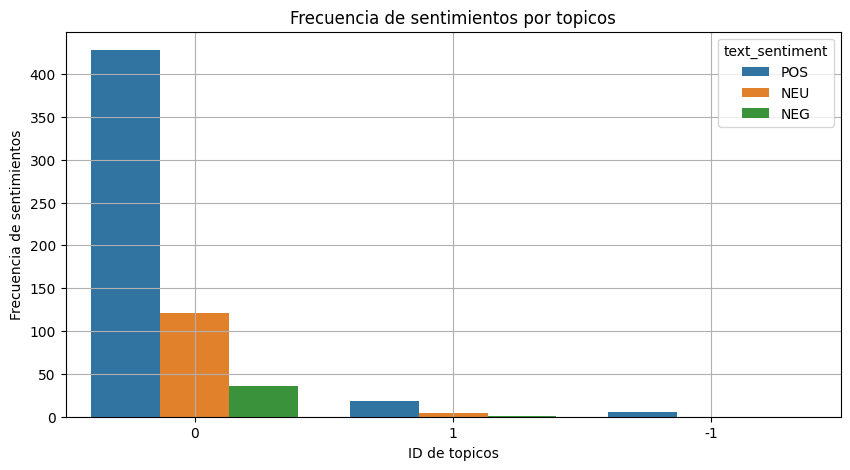

In [16]:
fig = plt.figure(figsize=(10, 5))
ax = sns.barplot(df_sentiment_by_topics, x='text_topic_id', y='count', hue='text_sentiment', order=df_sentiment_by_topics['text_topic_id'])
plt.title('Frecuencia de sentimientos por topicos')
plt.xlabel(xlabel='ID de topicos')
plt.ylabel(ylabel='Frecuencia de sentimientos')
#plt.yticks(np.arange(0, max(df_sentiment_by_topics['count'])+5, 1))
plt.grid()
plt.show()

Se puede apreciar como claramente, el topico o tiene mas registros en general, siendo considerablemente mayor la frecuencia de comentarios positivos (por encima de los 400), le siguen comentarios neutrales (entre 100 y 125) y comentarios negativos (entre 0 y 50).

### Asociación de keywords con emociones.



In [34]:
df_limpio['text_keywords'] = df_limpio['text_keywords'].apply(ast.literal_eval)

In [38]:
df_keywords_explode = df_limpio.explode('text_keywords')[['text_keywords', 'text_sentiment']]
df_keywords_explode[:5]

,text_keywords,text_sentiment
0,szechuan,NEG
0,sesame,NEG
0,rice,NEG
1,blowout,NEU
1,hair,NEU


In [39]:
df_sentiments_by_keywords = df_keywords_explode.groupby(by=['text_keywords'], as_index=False)['text_sentiment'].value_counts().sort_values(by='count', ascending=False)
df_sentiments_by_keywords[:5]

,text_keywords,text_sentiment,count
699,restaurant,POS,50
530,meal,POS,41
369,food,POS,31
643,pittsburgh,POS,26
297,dinner,POS,25


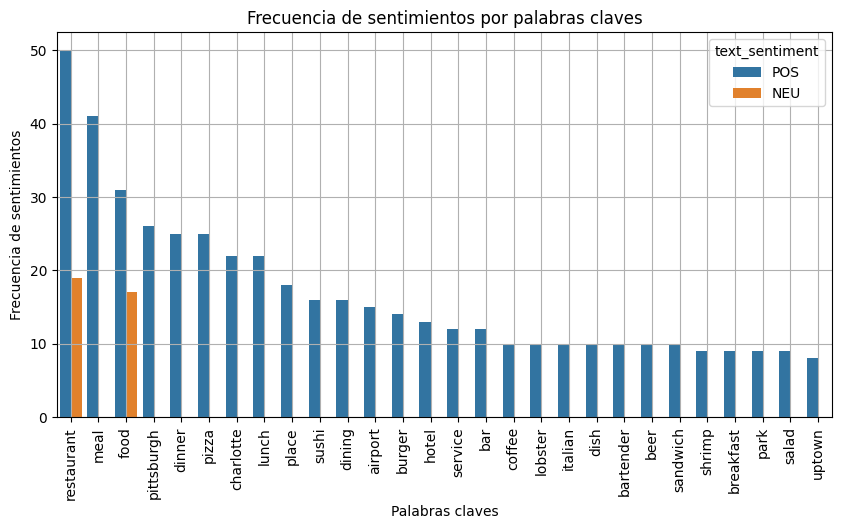

In [45]:
fig = plt.figure(figsize=(10, 5))
ax = sns.barplot(df_sentiments_by_keywords[:30], x='text_keywords', y='count', hue='text_sentiment', order=df_sentiments_by_keywords['text_keywords'][:30])
plt.title('Frecuencia de sentimientos por palabras claves')
plt.xlabel(xlabel='Palabras claves')
plt.ylabel(ylabel='Frecuencia de sentimientos')
plt.xticks(rotation=90)
#plt.yticks(np.arange(0, max(df_sentiment_by_topics['count'])+5, 1))
plt.grid()
plt.show()

Se puede ver como la mayoria de palabras claves aparecen en reviews con emociones positivas asociadas. Solo palabras claves realcionadas con 'food' y 'restaurante' tienen una frecuencia de aparición considerable, lo que podria indicar mal servicio en en la preparación de la comida de estos restaurantes.

### Evolución del sentimiento a lo largo del tiempo.



In [57]:
sentiment_through_time = df_limpio.groupby(['year', 'month'], as_index=False)['text_sentiment'].value_counts().sort_values(by=['year', 'month'])
sentiment_through_time[:5]

,year,month,text_sentiment,count
0,2006,7,POS,1
1,2006,9,POS,1
2,2006,10,POS,1
3,2007,4,POS,1
4,2007,12,NEU,1
...,...,...,...,...
176,2015,11,POS,7
177,2015,11,NEU,5
178,2015,11,NEG,1
179,2015,12,POS,8


In [64]:
sentiment_through_time['date'] = pd.to_datetime(sentiment_through_time[['year','month']].assign(day=1))

In [70]:
sentiment_pos_through_time_mask = sentiment_through_time['text_sentiment'] == 'POS'
sentiment_pos_through_time = sentiment_through_time[sentiment_pos_through_time_mask]

In [71]:
sentiment_neu_through_time_mask = sentiment_through_time['text_sentiment'] == 'NEU'
sentiment_neu_through_time = sentiment_through_time[sentiment_neu_through_time_mask]

In [72]:
sentiment_neg_through_time_mask = sentiment_through_time['text_sentiment'] == 'NEG'
sentiment_neg_through_time = sentiment_through_time[sentiment_neg_through_time_mask]

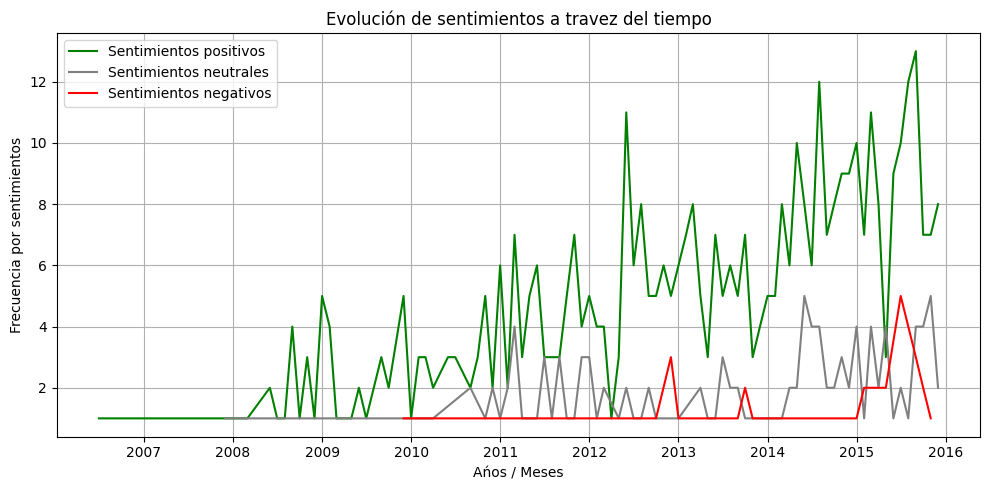

In [77]:
plt.figure(figsize=(10, 5))

# sentimientos positivos
ax = sns.lineplot(data=sentiment_pos_through_time, x=sentiment_pos_through_time['date'], y='count', label='Sentimientos positivos', color='green')

# sentimientos neutrales
ax = sns.lineplot(data=sentiment_neu_through_time, x=sentiment_neu_through_time['date'], y='count', label='Sentimientos neutrales', color='gray')

# sentimientos negativos
ax = sns.lineplot(data=sentiment_neg_through_time, x=sentiment_neg_through_time['date'], y='count', label='Sentimientos negativos', color='red')


plt.grid()
plt.title('Evolución de sentimientos a travez del tiempo')
plt.xlabel('Ańos / Meses')
plt.ylabel('Frecuencia por sentimientos')
plt.tight_layout()
plt.show()

En general se observa como las diferentes campańas adoptadas en los diferentes negocios, generaron mejor conexión con los usuarios, habiendo un aumento considerable de emociones y sentimientos positivos sobre negativos y neutrales.

### Entidades con sentimientos positivos asociados

### Entidades con sentimientos negativos asociados

Cualquier otro hallazgo relevante que descubras durante el análisis.